In [27]:
!pip install tensorflow scikit-fuzzy scipy numpy ucimlrepo matplotlib seaborn

In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [8]:
# Muat dataset iris dari file CSV/data
dataset = pd.read_csv('http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', header=None, sep=',')
# Menyusun data X (fitur) dan y (label)
X = dataset.iloc[:, :-1].values # 4 kolom pertama sebagai fitur
y = dataset.iloc[:, -1].values # Kolom terakhir sebagai label


In [9]:
# Mengonversi label dari string menjadi numerik
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y) # Mengubah label jadi 0, 1, 2

In [11]:
# Memisahkan dataset menjadi data latih dan data validasi dengan rasio 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
model = Sequential([
  Input(shape=X_train.shape[1:]),
  Dense(1000, activation='relu'),
  Dense(500, activation='relu'),
  Dense(300, activation='relu'),
  Dense(3, activation='softmax')
])

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1000)           │         5,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 300)            │       150,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 656,703 (2.51 MB)

 Trainable params: 656,703 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)


In [15]:
history = model.fit(
  X_train, y_train,
  epochs=50,
  batch_size=32,
  validation_data=(X_test, y_test)
)


Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.5667 - loss: 0.9812 - val_accuracy: 0.6333 - val_loss: 0.7324
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7500 - loss: 0.5544 - val_accuracy: 0.7000 - val_loss: 0.4718
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7500 - loss: 0.4539 - val_accuracy: 0.8333 - val_loss: 0.4066
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8417 - loss: 0.3649 - val_accuracy: 0.7667 - val_loss: 0.3427
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8167 - loss: 0.3198 - val_accuracy: 0.8333 - val_loss: 0.3098
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9167 - loss: 0.2588 - val_accuracy: 0.9333 - val_loss: 0.2173
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9583 - loss: 0.1961 - val_accuracy: 0.8667 - val_loss: 0.1948
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9500 - loss: 0.1522 - val_accuracy: 1.0000 - val_loss: 0.1447


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9667 - loss: 0.0696
Loss: 0.06964416056871414, Accuracy: 0.9666666388511658


<Axes: >

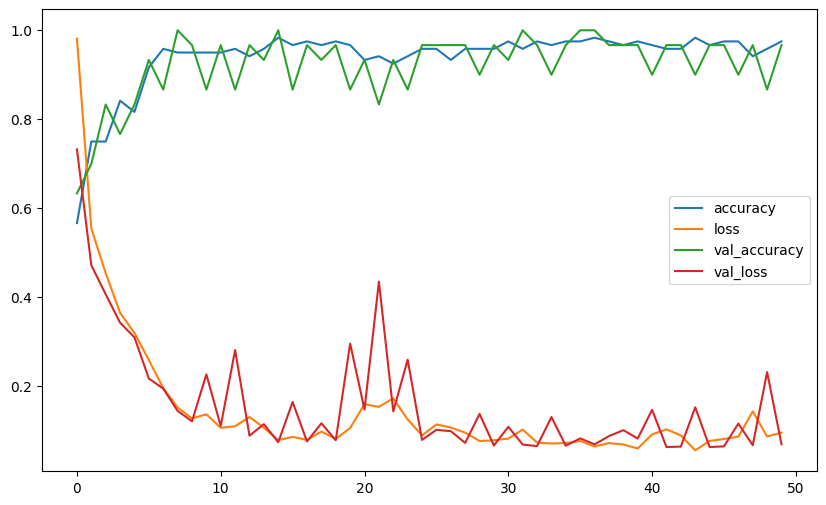

In [16]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss}, Accuracy: {accuracy}")
pd.DataFrame(history.history).plot(figsize=(10,6))

<Axes: >

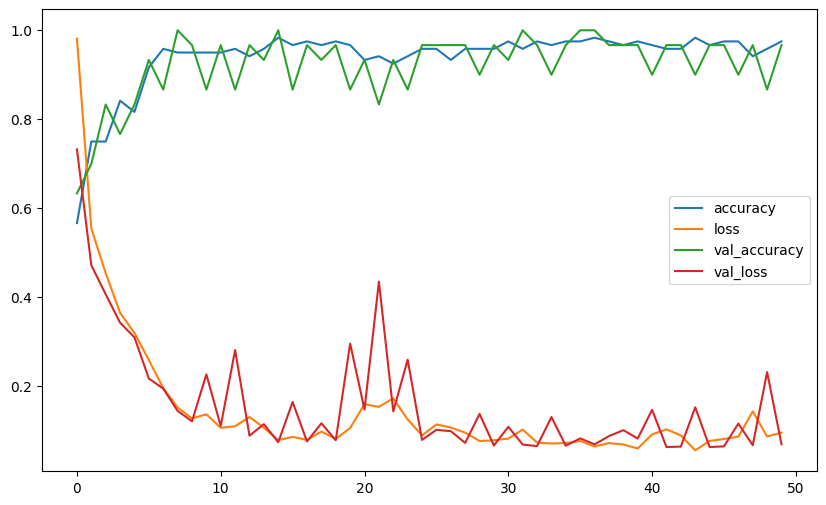

In [17]:
pd.DataFrame(history.history).plot(figsize=(10,6))

In [19]:
predictions = model.predict(X_test)
# Mengambil indeks dari nilai probabilitas tertinggi untuk setiap prediksi
predicted_classes = predictions.argmax(axis=1)
print("Prediksi:", predicted_classes)
print("Label Asli:", y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Prediksi: [1 0 2 1 1 0 1 2 2 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Label Asli: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


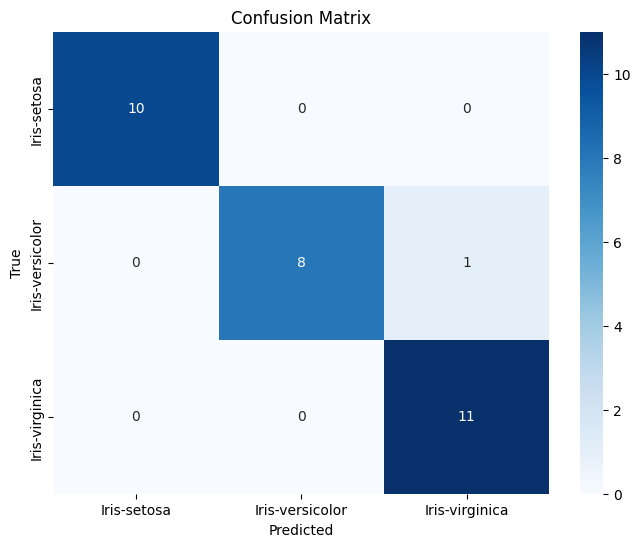

In [29]:
# Buat confusion matrix
cm = confusion_matrix(y_test, predicted_classes)
# Visualisasikan confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [30]:
# Fungsi untuk memprediksi data input baru
def predict_new_data():
  sepal_length = float(input("Masukkan sepal length: "))
  sepal_width = float(input("Masukkan sepal width: "))
  petal_length = float(input("Masukkan petal length: "))
  petal_width = float(input("Masukkan petal width: "))
  # Membuat data array baru
  new_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
  # Melakukan prediksi
  prediction = model.predict(new_data)
  predicted_class = prediction.argmax(axis=1)
  # Mengonversi hasil prediksi numerik menjadi label asli
  predicted_label = label_encoder.inverse_transform(predicted_class)
  print(f"Prediksi kelas: {predicted_label[0]}")
predict_new_data()

Masukkan sepal length: 5
Masukkan sepal width: 6
Masukkan petal length: 7
Masukkan petal width: 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Prediksi kelas: Iris-virginica
